#Drive Bağlantısı
**Amaç:** Google Colab sanal makinesine kendi Google Drive'ınızı bağlamak (mount etmek).

Bu kod çalıştırıldığında Google Colab sizden izin ister. İzin verdikten sonra Drive'ınızdaki dosyalar Colab dosya sisteminde /content/drive dizini altına eklenir.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
veri_yolu = '/content/drive/MyDrive/TECH ISTANBUL/Advertising.csv'

#Veri Görselleştirilmesi


In [7]:
import pandas as pd
import matplotlib.pyplot as plt # veri görselleştirme

In [8]:
veri = pd.read_csv(veri_yolu) # veri okuma işlemi için pandas kütüphanesi

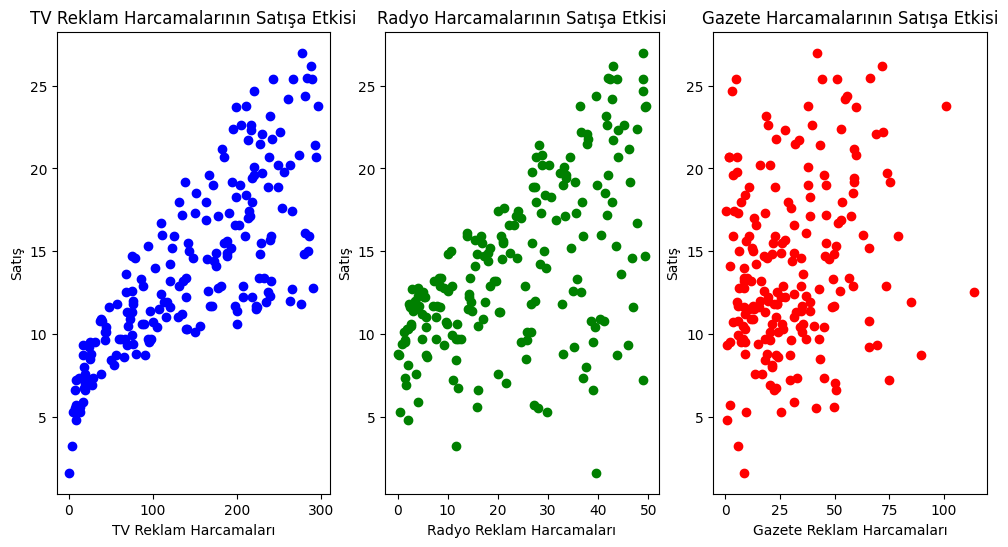

In [9]:
plt.figure(figsize=(12,6)) #grafiğin çizileceği pencere boyutu ayarlanır
plt.subplot(1,3,1) # 1 satır 3 sütunlu ızgara oluştur, ben 1 numaralı alana çizim yapacağım
plt.scatter(veri['TV'], veri['Sales'], color = 'blue') # scattter = saçılım grafiği
plt.title('TV Reklam Harcamalarının Satışa Etkisi')
plt.xlabel('TV Reklam Harcamaları')
plt.ylabel('Satış')

plt.subplot(1,3,2)
plt.scatter(veri['Radio'],veri['Sales'],color='green')
plt.title('Radyo Harcamalarının Satışa Etkisi')
plt.xlabel('Radyo Reklam Harcamaları')
plt.ylabel('Satış')

plt.subplot(1,3,3)
plt.scatter(veri['Newspaper'],veri['Sales'],color='red')
plt.title('Gazete Harcamalarının Satışa Etkisi')
plt.xlabel('Gazete Reklam Harcamaları')
plt.ylabel('Satış')

plt.show()

#Model Oluşturma
Burada, TV reklam harcamalarını kullanarak Satış rakamlarını tahmin eden bir Doğrusal Regresyon (Linear Regression) modeli kurup eğitiyorsunuz.

In [10]:
from sklearn.model_selection import train_test_split # makine öğrenmesi kütüphanesi
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error # modelin hata payını ölçmek için kullanırız

In [11]:
X = veri[['TV']] # veriyi matris/tablo olarak ele almamızı sağlar.
y = veri['Sales']

Scikit-learn kütüphanesindeki makine öğrenmesi modelleri ($X$) girdi (özellik/feature) verisini her zaman 2 boyutlu bir tablo şeklinde bekler. Çünkü model mantık olarak şuna göre tasarlanmıştır: Satırlar: Gözlemleri / Örnekleri temsil eder (Örn: 1. Gün, 2. Gün...). Sütunlar: Özellikleri temsil eder (Örn: TV Bütçesi, Radyo Bütçesi, Gazete Bütçesi...). Bugün modele sadece 1 özellik (TV) veriyor olsan bile, model altyapısı gereği senin bunu "1 sütunu olan bir tablo" şeklinde vermeni ister.

Küçük Bir Analoji

*   **veri['TV'] (1D):** Bir kâğıda yukarıdan aşağıya sadece sayıları dizip yazmak gibidir.

*   **veri[['TV']] (2D):** Bir Excel tablosu açıp, başlığına "TV" yazıp sayıları o sütunun altına doldurmak gibidir. Satırları ve sütun başlığı olan tam bir tablodur.





In [12]:
X_egitim, X_test, y_egitim, y_test = train_test_split(X, y, test_size=0.2, random_state= 34)
# Verinizin %80'i eğitim (egitim), %20'si test (test_size=0.2) için ayrılıyor.

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_egitim, y_egitim)

LinearRegression()

In [16]:
y_tahmin = model.predict(X_test) # Öğrendiklerine dayanarak, bu TV bütçeleri için ne kadar satış olacağını tahmin et

Elimizde iki tane sonuç kümesi oldu:

**y_tahmin:** Modelinizin tahmin ettiği satış rakamları.

**y_test:** Gerçekte gerçekleşmiş olan satış rakamları.

#MSE Hesabı
**Amaç:** Modelin tahminlerinin ne kadar isabetli olduğunu ölçmek.

**Mantık:** MSE (Mean Squared Error / Ortalama Kare Hata), gerçek satış değerleri (y_test) ile modelin tahmin ettiği değerler (y_tahmin) arasındaki farkların karelerinin ortalamasını alır.

**Yorumu:** Bu değer ne kadar küçükse, modelin tahminleri gerçek verilere o kadar yakındır (yani hatası azdır).

In [17]:
mse = mean_squared_error(y_test, y_tahmin)
print("MSE Hata Skoru: ", mse)

MSE Hata Skoru:  10.030469903877854


#Katsayılar ve Kesişim Noktası

In [18]:
print("Katsayı : ", model.coef_)
print("Kesişim Noktası : ", model.intercept_)

Katsayı :  [0.04719179]
Kesişim Noktası :  7.1033009592688074


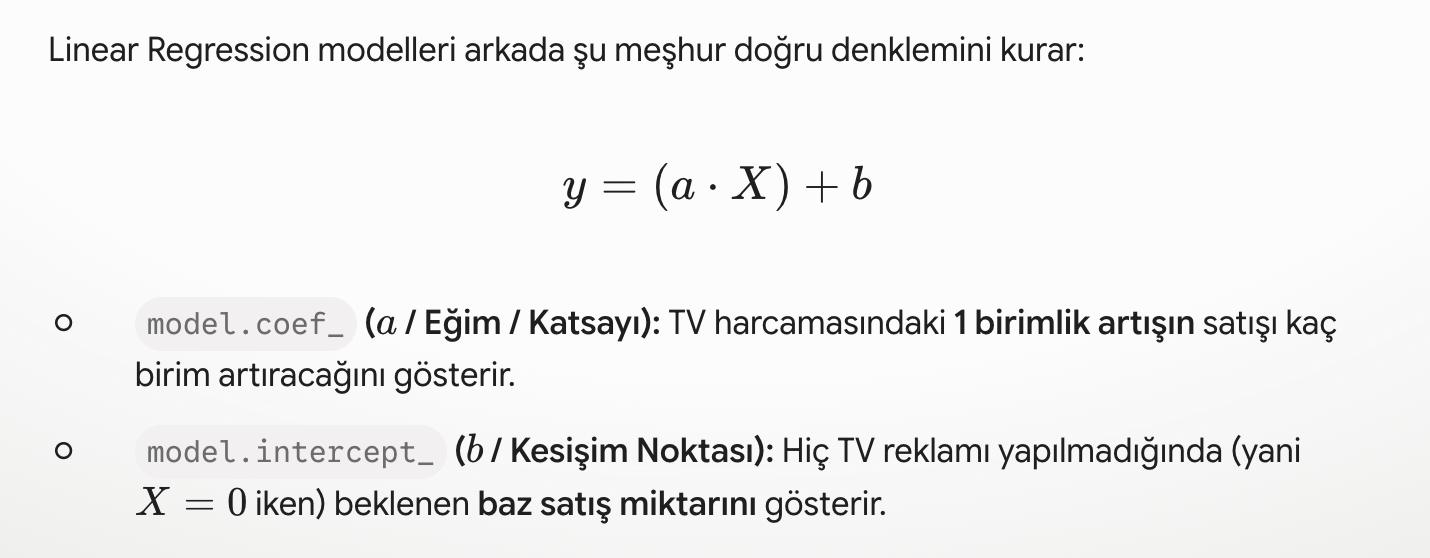

#Model Grafiği

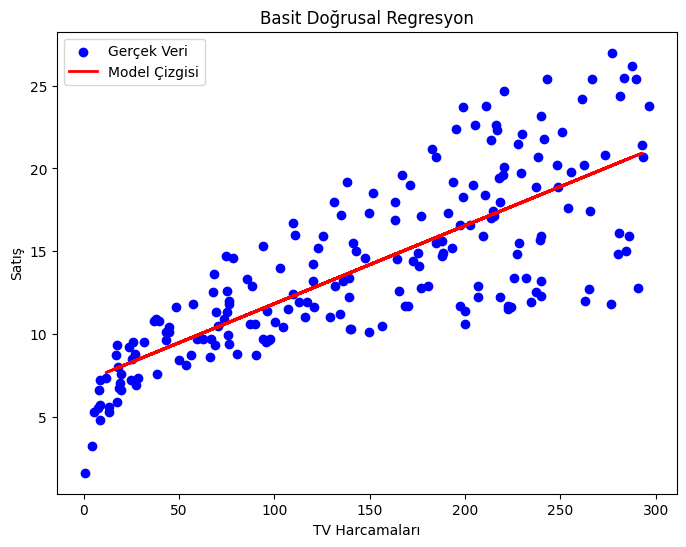

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label = 'Gerçek Veri')
plt.plot(X_test, y_tahmin, color ='red', linewidth=2, label='Model Çizgisi')
plt.title('Basit Doğrusal Regresyon')
plt.xlabel('TV Harcamaları')
plt.ylabel('Satış')
plt.legend()
plt.show()